# 11. Coordinates

Coordinate reference systems on point clouds, reprojection, shifts and
rotations, and registration matrices applied to a set of scans, with
`sylva.coords` and the `PointCloud` methods `translate`, `rotate` and
`recentre`. The [guide](../guide/coordinates.md) gives the rules behind
them.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import coords, filters

cloud = sylva.read(DATA / "litch_tile.laz")

## A CRS on the cloud

`sylva.read` takes the CRS of a LAS/LAZ file from its header. The tile is
stored in a local frame with its south-west corner at (0, 0), so its header
names none and `cloud.crs` is None. To have map coordinates to work with,
the tile is placed here in GDA2020 / MGA zone 52 (EPSG:7852), the zone of the
Litchfield plot, near the site. The offset is illustrative: it is not the
plot's surveyed position. A shift by whole metres is exact, so nothing is
lost on the way.

In [2]:
print("CRS read from the header:", cloud.crs)
site = coords.reproject(np.array([[130.7945, -13.1790, 0.0]]), "EPSG:7852", "EPSG:7844")   # longitude, latitude
E0, N0 = np.floor(site[0, :2])
plot = cloud.translate(E0, N0, 20.0)
plot.crs = "EPSG:7852"                     # an EPSG code, a PROJ string or WKT
info = coords.crs_info(plot.crs)
print(plot)
print(f"{info.name}: {info.proj4}")

CRS read from the header: None
PointCloud(n=1,553,677, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data'], crs='EPSG:7852')
GDA2020 / MGA zone 52: +proj=utm +zone=52 +south +ellps=GRS80 +units=m +no_defs


`sylva.write` stores the CRS in LAS/LAZ files as an OGC WKT record,
which PDAL, LAStools, CloudCompare and QGIS read, and `sylva.read` restores
it. PLY and text files carry no CRS.

In [3]:
import tempfile
tmp = Path(tempfile.mkdtemp())
sylva.write(plot, tmp / "plot_mga.laz")
back = sylva.read(tmp / "plot_mga.laz")
print("CRS read back:", back.crs[:48], "...")
print("the same CRS:", coords.same_crs(back.crs, 7852),
      "| largest coordinate change:", np.abs(back.xyz - plot.xyz).max(), "m")
sylva.write(plot[::50], tmp / "plot.ply")
print("CRS from a PLY file:", sylva.read(tmp / "plot.ply").crs)

CRS read back: PROJCS["GDA2020 / MGA zone 52",GEOGCS["GDA2020", ...
the same CRS: True | largest coordinate change: 0.0 m
CRS from a PLY file: None


## Reprojecting

`coords.transformation` reports, before anything is moved, how one CRS
reaches another: a conversion between projections on one datum is exact, a
Helmert datum change is exact to its published parameters, and a change
between datums with no parameters between them is a *null* transformation
that is not applied.

In [4]:
import pandas as pd

targets = {"EPSG:7844": "GDA2020 latitude, longitude", "EPSG:32752": "WGS 84 / UTM zone 52S",
           "EPSG:28352": "GDA94 / MGA zone 52"}
rows = []
for code, name in targets.items():
    t = coords.transformation(plot.crs, code)
    rows.append({"from EPSG:7852 to": f"{name} ({code})", "kind": t.kind, "exact": t.exact, "changes z": t.changes_z})
pd.DataFrame(rows)

,from EPSG:7852 to,kind,exact,changes z
0,"GDA2020 latitude, longitude (EPSG:7844)",conversion,True,False
1,WGS 84 / UTM zone 52S (EPSG:32752),null datum,False,False
2,GDA94 / MGA zone 52 (EPSG:28352),null datum,False,False


In [5]:
lonlat = coords.reproject(plot, "EPSG:7844")
print(lonlat.crs, "first point:", lonlat.xyz[0].round(7))
again = coords.reproject(lonlat, "EPSG:7852")
print(f"MGA -> latitude, longitude -> MGA: largest error {np.abs(again.xyz - plot.xyz).max() * 1e9:.1f} nm")

EPSG:7844 first point: [130.7946771 -13.1790023  20.31     ]


MGA -> latitude, longitude -> MGA: largest error 5.5 nm


To WGS 84 the transformation is a null one: the EPSG definition of
GDA2020 gives no parameters to WGS 84, so latitude and longitude are
carried across unchanged and the datum difference is not applied.
`reproject` still returns coordinates, and says so with an
`ApproximateTransformationWarning`. MGA zone 52 and UTM zone 52S use the
same projection on nearly identical ellipsoids, so the coordinates come out
the same to within a tenth of a millimetre; the warning is the only sign
that they should not have. Where a silent error of this kind
matters, turn the warning into an error with
`warnings.simplefilter("error", coords.ApproximateTransformationWarning)`.

In [6]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    utm = coords.reproject(plot, "EPSG:32752")
for w in caught:
    print(f"{w.category.__name__}: {w.message}")
print("largest change from the MGA coordinates:", np.abs(utm.xyz - plot.xyz).max(), "m")

largest change from the MGA coordinates: 4.6800822019577026e-05 m


A datum change with published parameters is applied. Suppose the same
numbers had been delivered in GDA94 / MGA zone 52: EPSG again gives no
parameters from GDA94 to GDA2020, but GDA2020 can be written as a PROJ
string carrying the published Helmert (EPSG:8048), and the shift is then
applied. A Helmert change treats z as ellipsoidal height and moves it too;
TLS heights are local or orthometric, so keep the original z afterwards.

In [7]:
gda94 = plot.copy()
gda94.crs = "EPSG:28352"                  # the same numbers, read as GDA94
gda2020 = ("+proj=utm +zone=52 +south +ellps=GRS80 +units=m +no_defs "
           "+towgs84=-0.06155,0.01087,0.04019,-0.0394924,-0.0327221,-0.0328979,0.009994")
print(coords.transformation("EPSG:28352", gda2020).note)
shifted = coords.reproject(gda94, gda2020)
d = shifted.xyz - gda94.xyz
print("shift east, north, up (m):", d.mean(axis=0).round(3),
      f"| its variation across the tile: {d.std(axis=0).max() * 1000:.4f} mm")
print(f"and back to GDA94: largest error {np.abs(coords.reproject(shifted, 'EPSG:28352').xyz - gda94.xyz).max() * 1000:.4f} mm")
shifted.xyz[:, 2] = gda94.z               # keep the heights
shifted.crs = "EPSG:7852"                 # and label the result with the code once shifted

datum change by the published Helmert (towgs84) parameters, through WGS 84; heights are treated as ellipsoidal


shift east, north, up (m): [ 0.955  1.528 -0.104] | its variation across the tile: 0.0002 mm


and back to GDA94: largest error 0.0006 mm


## Shifting, rotating and recentring

Map coordinates are large numbers. Float32 holds about seven significant
digits, so a northing of 8.5 million metres is stored to the nearest metre,
with errors of up to half a metre, and tools or formats that work in float32 lose the detail of the
cloud. `recentre` moves the cloud to a local origin, by default its minimum
corner rounded down to whole metres, and returns the offset;
`translate(*offset)` undoes it exactly.

In [8]:
local, offset = plot.recentre()
print("offset:", offset.tolist(), "| local extent:", local.bounds[0], "to", local.bounds[1])
for name, c in (("map", plot), ("local", local)):
    err = np.abs(c.xyz.astype(np.float32) - c.xyz).max(axis=0)
    print(f"largest float32 rounding of {name:5s} coordinates (x, y, z):", ", ".join(f"{e * 1000:.4g}" for e in err), "mm")

offset: [694486.0, 8542374.0, 19.0] | local extent: [0.    0.    0.933] to [20.    20.    21.106]
largest float32 rounding of map   coordinates (x, y, z): 31, 500, 0.001892 mm
largest float32 rounding of local coordinates (x, y, z): 0.000946, 0.0009462, 0.000946 mm


`rotate` takes degrees, counter-clockwise looking down the axis, about
the origin unless `about` names a point. Rotating map coordinates about the
origin swings the plot around the grid's (0, 0), thousands of kilometres
away, so rotate about the plot, or recentre first. The same operations are
available as 4 x 4 matrices, to compose with registration results.

rotated by 30 deg, back, and shifted to the map again: largest error 0.0 m
the same as a matrix: largest difference 0.0 m
rotated about the grid origin instead, the tile moves 4,436 km


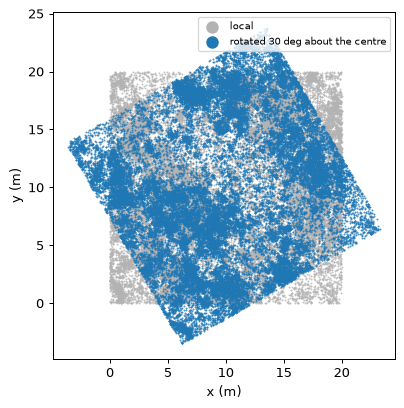

In [9]:
centre = local.xyz.mean(axis=0)
turned = local.rotate(30, about=centre)
restored = turned.rotate(-30, about=centre).translate(*offset)
print("rotated by 30 deg, back, and shifted to the map again: largest error",
      np.abs(restored.xyz - plot.xyz).max(), "m")
M = coords.rotation_matrix(30, about=centre)
print("the same as a matrix: largest difference", np.abs(local.transform(M).xyz - turned.xyz).max(), "m")
swung = plot.rotate(30)
print(f"rotated about the grid origin instead, the tile moves "
      f"{np.linalg.norm(swung.xyz.mean(axis=0) - plot.xyz.mean(axis=0)) / 1000:,.0f} km")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(local.x[::40], local.y[::40], s=0.2, c="0.7", label="local")
ax.scatter(turned.x[::40], turned.y[::40], s=0.2, c="C0", label="rotated 30 deg about the centre")
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)")
ax.legend(markerscale=20, loc="upper right", fontsize=8);

## Applying registration matrices

Registration yields one matrix per scan: RiSCAN SOPs, `.DAT` files, or the
`transforms.json` of `sylva.coreg`. `coords.apply_transforms` puts the scans
into one frame with them and can merge the result. The repository holds no
per-scan files, so three scans are made from the tile: the points within
9 m of three positions, each moved into its own scanner frame by the inverse
of an SOP-like matrix (the scanner 1.5 m above the ground, a heading, and a
1.2 degree tilt). The matrices are written as RiSCAN `.DAT` files and the
scans as LAZ files, named as RiSCAN exports them.

In [10]:
positions = {"ScanPos001": (4.0, 4.0, 25.0), "ScanPos002": (16.0, 5.0, 140.0), "ScanPos003": (10.0, 16.0, 260.0)}
(tmp / "DAT").mkdir()
seen = {}
for name, (x, y, heading) in positions.items():
    sop = (coords.translation_matrix(x, y, 1.5) @ coords.rotation_matrix(heading)
           @ coords.rotation_matrix(1.2, axis="x"))
    seen[name] = filters.range_filter(cloud, origin=(x, y, 1.5), max_range=9.0)
    np.savetxt(tmp / "DAT" / f"{name}.DAT", sop)                               # 4 rows of 4 numbers
    sylva.write(seen[name].transform(np.linalg.inv(sop)), tmp / f"{name}_5cm.laz")   # scanner frame
print(sorted(p.name for p in tmp.glob("ScanPos*")), sorted(p.name for p in (tmp / "DAT").iterdir()))

['ScanPos001_5cm.laz', 'ScanPos002_5cm.laz', 'ScanPos003_5cm.laz'] ['ScanPos001.DAT', 'ScanPos002.DAT', 'ScanPos003.DAT']


Each file is matched to a matrix by name: `ScanPos001_5cm.laz` takes
`ScanPos001.DAT`, because the file stem starts with the matrix name followed
by a separator.

PointCloud(n=992,128, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'scan_id', 'user_data'])
points per scan: [323874 282715 385539]
largest distance from the tile's own coordinates: 0.71 mm


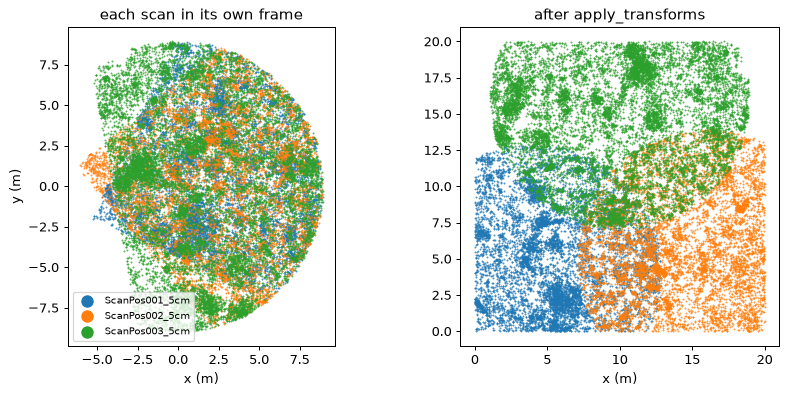

In [11]:
files = sorted(tmp.glob("ScanPos*_5cm.laz"))
merged = coords.apply_transforms(files, tmp / "DAT", merge=True)
reference = sylva.PointCloud.concatenate([seen[n] for n in positions])
print(merged)
print("points per scan:", np.bincount(merged.attrs["scan_id"]))
print(f"largest distance from the tile's own coordinates: {np.abs(merged.xyz - reference.xyz).max() * 1000:.2f} mm")

raw = [sylva.read(f) for f in files]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for i, r in enumerate(raw):
    ax[0].scatter(r.x[::30], r.y[::30], s=0.2, c=f"C{i}", label=files[i].stem)
ax[0].set(aspect="equal", title="each scan in its own frame", xlabel="x (m)", ylabel="y (m)")
ax[0].legend(markerscale=20, fontsize=8)
for i in range(len(files)):
    m = merged.attrs["scan_id"] == i
    ax[1].scatter(merged.x[m][::30], merged.y[m][::30], s=0.2, c=f"C{i}")
ax[1].set(aspect="equal", title="after apply_transforms", xlabel="x (m)");

The scans come back to within a millimetre of where they started. The
remaining error is the LAZ files' 1 mm coordinate scale, applied to the
points in their scanner frames before the matrices moved them back; with
clouds and matrices in memory the round trip is exact to float rounding.
`apply_transforms` also takes a mapping of clouds and matrices, a list by
position, a `transforms.json`, or a RiSCAN project, whose SOPs it applies,
and it writes the result with `out=`.

In [12]:
sops = {n: np.loadtxt(tmp / "DAT" / f"{n}.DAT") for n in positions}
scans = {n: seen[n].transform(np.linalg.inv(sops[n])) for n in positions}      # scanner frames, not rounded
in_memory = coords.apply_transforms(scans, sops)
print("in memory: largest error", max(np.abs(c.xyz - seen[n].xyz).max() for c, n in zip(in_memory, positions)), "m")

in memory: largest error 7.105427357601002e-15 m
